In [2]:
import kagglehub
import os

# Download Lending Club dataset
path = kagglehub.dataset_download("adarshsng/lending-club-loan-data-csv")

print("Downloaded to:", path)
print("Files:", os.listdir(path))

Downloaded to: C:\Users\user\.cache\kagglehub\datasets\adarshsng\lending-club-loan-data-csv\versions\1
Files: ['LCDataDictionary.xlsx', 'loan.csv']


In [3]:
import pandas as pd
import numpy as np

In [4]:
import pandas as pd
import os
df = pd.read_csv(os.path.join(path,"loan.csv"))

C:\Users\user\AppData\Local\Temp\ipykernel_4056\80460954.py:3: DtypeWarning: Columns (0: desc, 1: next_pymnt_d, 2: verification_status_joint, 3: sec_app_earliest_cr_line, 4: hardship_type, 5: hardship_reason, 6: hardship_status, 7: hardship_start_date, 8: hardship_end_date, 9: payment_plan_start_date, 10: hardship_loan_status, 11: debt_settlement_flag_date, 12: settlement_status, 13: settlement_date) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(path,"loan.csv"))


In [5]:
import pandas as pd
import os

In [6]:
# Show every column that contains "fico"
[c for c in df.columns if "fico" in c.lower()]

[]

In [7]:
# Find columns related to credit scores
[c for c in df.columns if "score" in c.lower() or "credit" in c.lower() or "fico" in c.lower()]

['last_credit_pull_d', 'total_il_high_credit_limit']

In [8]:
# Show the first 40 column names
print(df.columns.tolist()[:40])

['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv']


In [9]:
print(df["int_rate"].dtype)

float64


In [10]:
# Clean interest rate only if it's text
if df["int_rate"].dtype == "object":
    df["int_rate"] = (
        df["int_rate"]
        .str.replace("%", "", regex=False)
        .astype(float)
    )

print(df["int_rate"].head())

0    13.56
1    18.94
2    17.97
3    18.94
4    16.14
Name: int_rate, dtype: float64


In [11]:
print(df["term"].dtype)
print(df["term"].head())

str
0     36 months
1     60 months
2     36 months
3     36 months
4     60 months
Name: term, dtype: str


In [12]:
# Clean loan term: " 36 months" -> 36
df["term"] = (
    df["term"]
      .astype(str)                 # Make everything a string
      .str.strip()                 # Remove leading/trailing spaces
      .str.extract(r"(\d+)")[0]    # Extract 36 or 60
      .astype(int)
)

print(df["term"].head())
print(df["term"].unique())

0    36
1    60
2    36
3    36
4    60
Name: term, dtype: int64
[36 60]


In [13]:
# Interest rate
if df["int_rate"].dtype == "object":
    df["int_rate"] = df["int_rate"].str.replace("%", "", regex=False).astype(float)

# Loan term
if df["term"].dtype == "object":
    df["term"] = df["term"].str.extract(r"(\d+)").astype(int)
else:
    df["term"] = df["term"].astype(int)

In [14]:
import numpy as np

# Interest rate
df["int_rate"] = pd.to_numeric(df["int_rate"], errors="coerce")

# Employment length: "10+ years", "< 1 year", etc.
df["emp_length"] = (
    df["emp_length"]
    .fillna("0")
    .astype(str)
    .str.replace(r"10\+", "10", regex=True)
    .str.replace(r"< 1", "0", regex=True)
    .str.extract(r"(\d+)")[0]
    .fillna(0)
    .astype(int)
)

# DTI
df["dti"] = pd.to_numeric(df["dti"], errors="coerce")
df["dti"] = df["dti"].replace([-1, 999], np.nan)

# Fill missing values
df["annual_inc"] = df["annual_inc"].fillna(df["annual_inc"].median())
df["dti"] = df["dti"].fillna(df["dti"].median())

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2260668 entries, 0 to 2260667
Columns: 145 entries, id to settlement_term
dtypes: float64(105), int64(6), str(34)
memory usage: 2.8 GB
None


In [15]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

id                                            2260668
member_id                                     2260668
url                                           2260668
orig_projected_additional_accrued_interest    2252242
hardship_amount                               2250055
                                               ...   
pub_rec                                            29
delinq_amnt                                        29
delinq_2yrs                                        29
acc_now_delinq                                     29
zip_code                                            1
Length: 110, dtype: int64

In [16]:
import pandas as pd
import numpy as np
import os

# Original dataset
loan_df = pd.read_csv(os.path.join(path, "loan.csv"), low_memory=False)

# Keep only the columns we need
selected_columns = [
    "loan_amnt",
    "term",
    "int_rate",
    "grade",
    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "purpose",
    "dti",
    "loan_status"
]

df = loan_df[selected_columns].copy()

In [17]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

emp_length    146907
dti             1711
annual_inc         4
dtype: int64

In [18]:
# Remove Current loans
df = df[df["loan_status"] != "Current"].copy()

# Create target column
df["target"] = df["loan_status"].isin(["Charged Off", "Default"]).astype(int)

# Clean term
df["term"] = (
    df["term"]
    .astype(str)
    .str.strip()
    .str.extract(r"(\d+)")[0]
    .astype(int)
)

# Clean interest rate
df["int_rate"] = pd.to_numeric(df["int_rate"], errors="coerce")

# Clean employment length
df["emp_length"] = (
    df["emp_length"]
    .fillna("0")
    .astype(str)
    .str.replace("10+ years", "10 years")
    .str.replace("< 1 year", "0 years")
    .str.extract(r"(\d+)")[0]
    .fillna(0)
    .astype(int)
)

# Clean DTI
df["dti"] = pd.to_numeric(df["dti"], errors="coerce")
df["dti"] = df["dti"].replace([-1, 999], np.nan)

# Fill missing values
df["annual_inc"] = df["annual_inc"].fillna(df["annual_inc"].median())
df["dti"] = df["dti"].fillna(df["dti"].median())

In [19]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

Series([], dtype: int64)

In [20]:
print(df.shape)
print(df.dtypes)
df.head()

(1340973, 12)
loan_amnt                int64
term                     int64
int_rate               float64
grade                      str
emp_length               int64
home_ownership             str
annual_inc             float64
verification_status        str
purpose                    str
dti                    float64
loan_status                str
target                   int64
dtype: object


,loan_amnt,term,int_rate,grade,emp_length,home_ownership,annual_inc,verification_status,purpose,dti,loan_status,target
100,30000,36,22.35,D,5,MORTGAGE,100000.0,Source Verified,debt_consolidation,30.46,Fully Paid,0
152,40000,60,16.14,C,0,MORTGAGE,45000.0,Verified,credit_card,50.53,Fully Paid,0
170,20000,36,7.56,A,10,MORTGAGE,100000.0,Not Verified,credit_card,18.92,Fully Paid,0
186,4500,36,11.31,B,10,RENT,38500.0,Not Verified,credit_card,4.64,Fully Paid,0
215,8425,36,27.27,E,3,MORTGAGE,450000.0,Verified,credit_card,12.37,Fully Paid,0


In [21]:
df["loan_status"].value_counts()

loan_status
Fully Paid                                             1041952
Charged Off                                             261655
Late (31-120 days)                                       21897
In Grace Period                                           8952
Late (16-30 days)                                         3737
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     31
Name: count, dtype: int64

In [22]:
df["target"].value_counts()

target
0    1079287
1     261686
Name: count, dtype: int64

In [23]:
default_rate = df["target"].mean() * 100

print(f"Default rate: {default_rate:.2f}%")

Default rate: 19.51%


In [24]:
df.describe()

,loan_amnt,term,int_rate,emp_length,annual_inc,dti,target
count,1.340973e+06,1.340973e+06,1.340973e+06,1.340973e+06,1.340973e+06,1.340973e+06,1.340973e+06
mean,1.447239e+04,4.189828e+01,1.331854e+01,5.610421e+00,7.619615e+04,1.827097e+01,1.951464e-01
std,8.735345e+03,1.033292e+01,4.785973e+00,3.845698e+00,7.047915e+04,9.899650e+00,3.963135e-01
min,5.000000e+02,3.600000e+01,5.310000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,8.000000e+03,3.600000e+01,9.760000e+00,2.000000e+00,4.576000e+04,1.180000e+01,0.000000e+00
50%,1.200000e+04,3.600000e+01,1.279000e+01,6.000000e+00,6.500000e+04,1.763000e+01,0.000000e+00
75%,2.000000e+04,3.600000e+01,1.602000e+01,1.000000e+01,9.000000e+04,2.407000e+01,0.000000e+00
max,4.000000e+04,6.000000e+01,3.099000e+01,1.000000e+01,1.099920e+07,9.915700e+02,1.000000e+00


In [25]:
grade_default = (
    df.groupby("grade")["target"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values()
)

print(grade_default)

grade
A     6.02
B    13.16
C    21.76
D    29.18
E    37.05
F    43.50
G    47.01
Name: target, dtype: float64


In [26]:
print(f"Default rate: {default_rate:.2f}%")
print(f"Non-default rate: {100 - default_rate:.2f}%")

Default rate: 19.51%
Non-default rate: 80.49%


In [27]:
grade_default = (
    df.groupby("grade")["target"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

print(grade_default)

grade
G    47.01
F    43.50
E    37.05
D    29.18
C    21.76
B    13.16
A     6.02
Name: target, dtype: float64


In [28]:
import plotly.express as px

grade_default_df = grade_default.reset_index()
grade_default_df.columns = ["grade", "default_rate"]

fig = px.bar(
    grade_default_df,
    x="grade",
    y="default_rate",
    text="default_rate",
    title="Default Rate by Loan Grade",
    labels={
        "grade": "Loan Grade",
        "default_rate": "Default Rate (%)"
    }
)

fig.update_traces(texttemplate="%{text:.2f}%", textposition="outside")
fig.show()

as loan grade deteriorates from Ato G,the probability of dafault increases substantially
### Business Insight: Loan Grade and Default Risk

Loan grade shows a strong relationship with default risk. Grade A loans have
the lowest default rate at 6.02%, while Grade G loans have the highest
default rate at 47.01%.

Default rates increase consistently across the grades, rising from 6.02% for
Grade A to 47.01% for Grade G. This represents a 40.99 percentage-point
difference.

This suggests that loan grade is an important predictor of borrower default
risk and may be useful in the LoanGuard AI prediction model.

In [29]:
interest_default = (
    df.groupby("target")["int_rate"]
      .mean()
      .round(2)
)

print(interest_default)

target
0    12.74
1    15.71
Name: int_rate, dtype: float64


In [30]:
non_default_rate = df.loc[df["target"] == 0, "int_rate"].mean()
default_interest_rate = df.loc[df["target"] == 1, "int_rate"].mean()

difference = default_interest_rate - non_default_rate

print(f"Average interest rate for non-defaults: {non_default_rate:.2f}%")
print(f"Average interest rate for defaults: {default_interest_rate:.2f}%")
print(f"Difference: {difference:.2f} percentage points")

Average interest rate for non-defaults: 12.74%
Average interest rate for defaults: 15.71%
Difference: 2.97 percentage points


In [31]:
import plotly.express as px

interest_comparison = (
    df.groupby("target")["int_rate"]
      .mean()
      .reset_index()
)

interest_comparison["loan_outcome"] = interest_comparison["target"].map({
    0: "Non-default",
    1: "Default"
})

fig = px.bar(
    interest_comparison,
    x="loan_outcome",
    y="int_rate",
    text="int_rate",
    title="Average Interest Rate by Loan Outcome",
    labels={
        "loan_outcome": "Loan Outcome",
        "int_rate": "Average Interest Rate (%)"
    }
)

fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="outside"
)

fig.show()

### Business Insight: Interest Rate and Default Risk

The average interest rate for loans that defaulted was 15.71%, compared with
12.74% for loans that did not default.

This represents a difference of 2.97 percentage points, suggesting that higher
interest rates are associated with increased default risk in the dataset.

However, this relationship does not necessarily mean that higher interest
rates directly cause default. Interest rates may also reflect the lender's
assessment of borrower risk.

In [32]:
purpose_default = (
    df.groupby("purpose")["target"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

print(purpose_default)

purpose
small_business        28.44
renewable_energy      23.13
moving                22.63
medical               21.14
house                 20.68
debt_consolidation    20.68
other                 20.37
vacation              18.67
major_purchase        18.09
home_improvement      17.34
credit_card           16.63
car                   14.25
educational           13.24
wedding               11.87
Name: target, dtype: float64


In [33]:
### Business Insight: Loan Purpose and Default Risk

Default rates vary considerably by loan purpose. Small business loans have the
highest default rate at 28.44%, while wedding loans have the lowest at 11.87%.

The 16.57 percentage-point difference suggests that loan purpose may be
associated with borrower default risk.

However, loan purpose alone should not be interpreted as a direct cause of
default. Differences may also be influenced by borrower characteristics,
loan terms, income, interest rates, and other factors.

SyntaxError: invalid syntax (1129516247.py, line 3)

In [34]:
emp_default = (
    df.groupby("emp_length")["target"]
      .mean()
      .mul(100)
      .round(2)
      .sort_index()
)

print(emp_default)

emp_length
0     22.52
1     20.01
2     19.35
3     19.51
4     19.32
5     19.15
6     18.95
7     19.15
8     19.61
9     19.58
10    18.40
Name: target, dtype: float64


### Business Insight: Employment Length and Default Risk

Default rates vary only modestly across employment lengths. Borrowers with
less than one year of employment have the highest default rate at 22.52%,
while borrowers with 10 or more years of employment have the lowest rate at
18.40%.

The relatively small 4.12 percentage-point difference suggests that
employment length alone has a weaker association with default risk compared
with factors such as loan grade.

Employment length may still provide useful information when combined with
other borrower and loan characteristics.

In [35]:
home_default = (
    df.groupby("home_ownership")["target"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

print(home_default)

home_ownership
RENT        22.64
OWN         20.11
ANY         17.93
MORTGAGE    16.87
OTHER       14.84
NONE        13.21
Name: target, dtype: float64


In [36]:
home_default_df = home_default.reset_index()
home_default_df.columns = ["home_ownership", "default_rate"]

fig = px.bar(
    home_default_df,
    x="home_ownership",
    y="default_rate",
    text="default_rate",
    title="Default Rate by Home Ownership",
    labels={
        "home_ownership": "Home Ownership",
        "default_rate": "Default Rate (%)"
    }
)

fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="outside"
)

fig.show()

### Business Insight: Home Ownership and Default Risk

Default rates vary across home ownership categories. Borrowers who rent have
the highest observed default rate at 22.64%, while borrowers with a mortgage
have a lower default rate of 16.87%.

The 5.77 percentage-point difference suggests that home ownership status may
provide useful information when assessing default risk.

However, home ownership should not be interpreted as a direct cause of
default, since other borrower and loan characteristics may contribute to
these differences.

In [37]:
df.groupby("target")[["loan_amnt", "annual_inc", "dti"]].mean().round(2)

,loan_amnt,annual_inc,dti
target,,,
0,14211.35,77619.13,17.82
1,15549.01,70327.28,20.13


### Business Insight: Financial Characteristics and Default Risk

Defaulters had a higher average loan amount ($15,549.01) compared with
non-defaulters ($14,211.35).

At the same time, defaulters had a lower average annual income
($70,327.28) than non-defaulters ($77,619.13).

Defaulters also had a higher average debt-to-income ratio (20.13) compared
with non-defaulters (17.82).

These findings suggest that higher borrowing amounts, lower income, and
greater debt-to-income ratios may be associated with increased default risk.
However, these are associations and do not establish causation.

In [38]:
df["dti_group"] = pd.cut(
    df["dti"],
    bins=[0, 10, 20, 30, 40, 50, 100],
    labels=[
        "0-10",
        "10-20",
        "20-30",
        "30-40",
        "40-50",
        "50+"
    ]
)

dti_default = (
    df.groupby("dti_group", observed=True)["target"]
      .mean()
      .mul(100)
      .round(2)
)

print(dti_default)

dti_group
0-10     14.45
10-20    17.49
20-30    22.54
30-40    28.40
40-50    30.65
50+      24.78
Name: target, dtype: float64


### Business Insight: Debt-to-Income Ratio and Default Risk

Default rates generally increase as debt-to-income (DTI) rises. The default
rate increases from 14.45% among borrowers with a DTI of 0–10 to 30.65% among
borrowers with a DTI of 40–50.

This represents a 16.20 percentage-point increase, suggesting that higher
levels of borrower debt relative to income are associated with greater
default risk.

The 50+ DTI group has a lower observed default rate of 24.78%. This deviation
from the overall pattern should be interpreted cautiously and may be related
to the number or characteristics of borrowers in this category.

In [39]:
dti_counts = df["dti_group"].value_counts().sort_index()

print(dti_counts)

dti_group
0-10     244562
10-20    559591
20-30    407530
30-40    121525
40-50      3993
50+        2369
Name: count, dtype: int64


### Business Insight: Debt-to-Income Ratio and Default Risk

Default rates generally increase as debt-to-income (DTI) rises. The default
rate increases from 14.45% for borrowers with a DTI of 0–10 to 30.65% for
borrowers with a DTI of 40–50.

However, the higher DTI categories contain substantially fewer observations
than the lower DTI categories. In particular, the 40–50 and 50+ groups contain
3,993 and 2,369 loans respectively. Therefore, the decline in default rate
observed in the 50+ group should be interpreted cautiously.

Overall, the analysis suggests that increasing DTI is generally associated
with higher default risk, although the relationship becomes less stable at
the extreme DTI levels due to smaller sample sizes.

In [40]:
df["loan_amount_group"] = pd.cut(
    df["loan_amnt"],
    bins=[0, 5000, 10000, 15000, 20000, 25000, 30000, 40000, 50000],
    labels=[
        "0-5K",
        "5K-10K",
        "10K-15K",
        "15K-20K",
        "20K-25K",
        "25K-30K",
        "30K-40K",
        "40K-50K"
    ]
)

loan_amount_default = (
    df.groupby("loan_amount_group", observed=True)["target"]
      .mean()
      .mul(100)
      .round(2)
)

print(loan_amount_default)

loan_amount_group
0-5K       15.55
5K-10K     16.89
10K-15K    20.33
15K-20K    22.07
20K-25K    22.17
25K-30K    22.48
30K-40K    23.45
Name: target, dtype: float64


### Business Insight: Loan Amount and Default Risk

Default rates generally increase as loan amounts increase. Loans between
$0–5,000 have a default rate of 15.55%, compared with 23.45% for loans
between $30,000 and $40,000.

This represents a 7.90 percentage-point difference and suggests that larger
loan amounts are associated with higher default risk in the dataset.

The relationship becomes relatively stable above $15,000, indicating that
loan amount may provide useful predictive information but is unlikely to
explain default risk on its own.

In [41]:
print(df["loan_status"].value_counts())

loan_status
Fully Paid                                             1041952
Charged Off                                             261655
Late (31-120 days)                                       21897
In Grace Period                                           8952
Late (16-30 days)                                         3737
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     31
Name: count, dtype: int64


In [42]:
# Keep only loans with clearly resolved outcomes
valid_statuses = ["Fully Paid", "Charged Off", "Default"]

df_model = df[df["loan_status"].isin(valid_statuses)].copy()

# Create final target
# 0 = Fully Paid
# 1 = Default / Charged Off
df_model["target"] = df_model["loan_status"].isin(
    ["Charged Off", "Default"]
).astype(int)

print(df_model["loan_status"].value_counts())

loan_status
Fully Paid     1041952
Charged Off     261655
Default             31
Name: count, dtype: int64


In [43]:
print(df_model["target"].value_counts())
print("\nDefault rate:", round(df_model["target"].mean() * 100, 2), "%")

target
0    1041952
1     261686
Name: count, dtype: int64

Default rate: 20.07 %


In [44]:
print(df_model.shape)
print(df_model.isnull().sum())

(1303638, 14)
loan_amnt                 0
term                      0
int_rate                  0
grade                     0
emp_length                0
home_ownership            0
annual_inc                0
verification_status       0
purpose                   0
dti                       0
loan_status               0
target                    0
dti_group              1257
loan_amount_group         0
dtype: int64


In [45]:
df_model.head()

,loan_amnt,term,int_rate,grade,emp_length,home_ownership,annual_inc,verification_status,purpose,dti,loan_status,target,dti_group,loan_amount_group
100,30000,36,22.35,D,5,MORTGAGE,100000.0,Source Verified,debt_consolidation,30.46,Fully Paid,0,30-40,25K-30K
152,40000,60,16.14,C,0,MORTGAGE,45000.0,Verified,credit_card,50.53,Fully Paid,0,50+,30K-40K
170,20000,36,7.56,A,10,MORTGAGE,100000.0,Not Verified,credit_card,18.92,Fully Paid,0,10-20,15K-20K
186,4500,36,11.31,B,10,RENT,38500.0,Not Verified,credit_card,4.64,Fully Paid,0,0-10,0-5K
215,8425,36,27.27,E,3,MORTGAGE,450000.0,Verified,credit_card,12.37,Fully Paid,0,10-20,5K-10K


In [46]:
features = [
    "loan_amnt",
    "term",
    "int_rate",
    "grade",
    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "purpose",
    "dti"
]

print(features)

['loan_amnt', 'term', 'int_rate', 'grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'dti']


In [47]:
print(df_model[features].head())

     loan_amnt  term  int_rate grade  emp_length home_ownership  annual_inc  \
100      30000    36     22.35     D           5       MORTGAGE    100000.0   
152      40000    60     16.14     C           0       MORTGAGE     45000.0   
170      20000    36      7.56     A          10       MORTGAGE    100000.0   
186       4500    36     11.31     B          10           RENT     38500.0   
215       8425    36     27.27     E           3       MORTGAGE    450000.0   

    verification_status             purpose    dti  
100     Source Verified  debt_consolidation  30.46  
152            Verified         credit_card  50.53  
170        Not Verified         credit_card  18.92  
186        Not Verified         credit_card   4.64  
215            Verified         credit_card  12.37  


In [48]:
print(df_model["target"].value_counts())

target
0    1041952
1     261686
Name: count, dtype: int64


In [49]:
df_model["loan_amnt"]
df_model["term"]
df_model["int_rate"]

100        22.35
152        16.14
170         7.56
186        11.31
215        27.27
           ...  
2260654    17.09
2260655    30.65
2260656    30.17
2260658    16.02
2260664    25.82
Name: int_rate, Length: 1303638, dtype: float64

In [50]:
print(df_model.shape)
print(df_model["target"].value_counts())
print(df_model.isnull().sum())

(1303638, 14)
target
0    1041952
1     261686
Name: count, dtype: int64
loan_amnt                 0
term                      0
int_rate                  0
grade                     0
emp_length                0
home_ownership            0
annual_inc                0
verification_status       0
purpose                   0
dti                       0
loan_status               0
target                    0
dti_group              1257
loan_amount_group         0
dtype: int64


In [51]:
df_model = df_model.drop(columns=["loan_status", "dti_group", "loan_amount_group"], errors="ignore")

print(df_model.columns)

Index(['loan_amnt', 'term', 'int_rate', 'grade', 'emp_length',
       'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'dti',
       'target'],
      dtype='str')


In [52]:
X = df_model.drop(columns="target")
y = df_model["target"]

print(X.shape)
print(y.shape)

(1303638, 10)
(1303638,)


In [53]:
from sklearn.model_selection import train_test_split

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (1042910, 10)
Testing set: (260728, 10)


In [55]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_features = [
    "loan_amnt",
    "term",
    "int_rate",
    "emp_length",
    "annual_inc",
    "dti"
]

categorical_features = [
    "grade",
    "home_ownership",
    "verification_status",
    "purpose"
]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [56]:
from sklearn.linear_model import LogisticRegression

log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning:

lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [57]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_features = [
    "loan_amnt",
    "term",
    "int_rate",
    "emp_length",
    "annual_inc",
    "dti"
]

categorical_features = [
    "grade",
    "home_ownership",
    "verification_status",
    "purpose"
]

# Numeric preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())      # ⭐ New step
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=3000,      # Increase iterations
        random_state=42
    ))
])

log_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

Model Training Note: Logistic Regression initially produced a convergence warning because the numerical features were on different scales and the dataset contained over 1.3 million observations. The preprocessing pipeline was updated to standardize numerical variables using StandardScaler, and the maximum number of iterations was increased from 1000 to 3000 to allow the optimizer to converge.

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

log_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=3000,
        random_state=42,
        solver="lbfgs"
    ))
])

log_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [60]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob), 4))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.8006
Precision: 0.5377
Recall   : 0.0474
F1 Score : 0.0872
ROC AUC  : 0.7024

Confusion Matrix
[[206256   2135]
 [ 49854   2483]]

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.99      0.89    208391
           1       0.54      0.05      0.09     52337

    accuracy                           0.80    260728
   macro avg       0.67      0.52      0.49    260728
weighted avg       0.75      0.80      0.73    260728



In [61]:
LogisticRegression(
    max_iter=3000,
    random_state=42,
    class_weight="balanced"
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

log_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ))
])

log_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [63]:
y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:,1]

In [64]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc:.4f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.6332
Precision: 0.3090
Recall   : 0.6692
F1 Score : 0.4228
ROC AUC  : 0.7025

Confusion Matrix
[[130075  78316]
 [ 17311  35026]]

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.62      0.73    208391
           1       0.31      0.67      0.42     52337

    accuracy                           0.63    260728
   macro avg       0.60      0.65      0.58    260728
weighted avg       0.77      0.63      0.67    260728



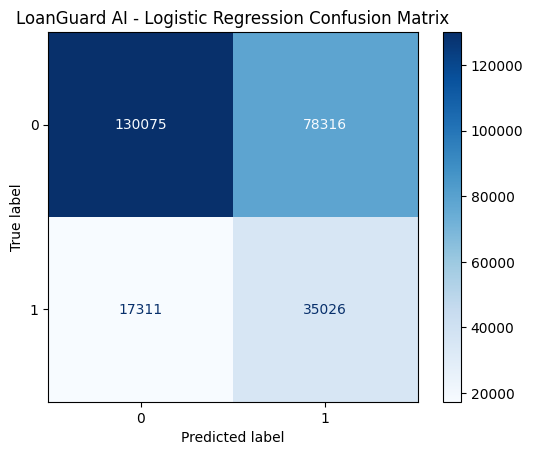

In [65]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("LoanGuard AI - Logistic Regression Confusion Matrix")
plt.show()

In [66]:
# Calculate confusion matrix metrics based on the values in the image
# True label (y-axis): 0, 1
# Predicted label (x-axis): 0, 1
# Note: Looking at the image closely, the orientation is sideways. 
# "True label" is at the top axis (0 and 1). "Predicted label" is on the left axis (0 and 1).
# Let's map the quadrants carefully:
# Top-left (True=0, Pred=0): 130075
# Top-right (True=1, Pred=0): 17311
# Bottom-left (True=0, Pred=1): 78316
# Bottom-right (True=1, Pred=1): 35026

TN = 130075 # True Negative (True 0, Pred 0)
FP = 78316  # False Positive (True 0, Pred 1)
FN = 17311  # False Negative (True 1, Pred 0)
TP = 35026  # True Positive (True 1, Pred 1)

total = TN + FP + FN + TP
accuracy = (TP + TN) / total
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)

print(f"Total: {total}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1: {f1:.4f}")

Total: 260728
Accuracy: 0.6332
Precision: 0.3090
Recall: 0.6692
F1: 0.4228


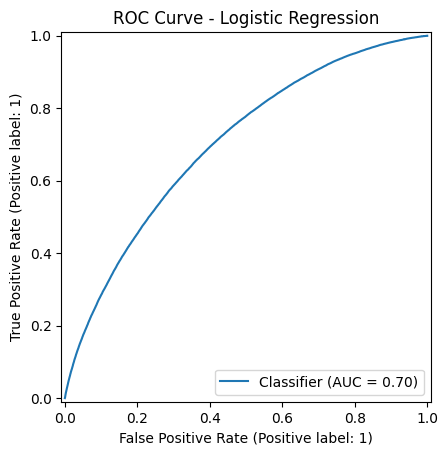

In [67]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_prob)

plt.title("ROC Curve - Logistic Regression")
plt.show()

In [68]:
import pandas as pd
import numpy as np

# Get feature names after preprocessing
feature_names = log_model.named_steps["preprocessor"].get_feature_names_out()

coefficients = log_model.named_steps["classifier"].coef_[0]

importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

importance["Importance"] = np.abs(importance["Coefficient"])

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(15)

,Feature,Coefficient,Importance
6,cat__grade_A,-0.909400,0.909400
35,cat__purpose_wedding,-0.391196,0.391196
33,cat__purpose_small_business,0.358596,0.358596
12,cat__grade_G,0.355771,0.355771
11,cat__grade_F,0.337593,0.337593
7,cat__grade_B,-0.316041,0.316041
10,cat__grade_E,0.294849,0.294849
9,cat__grade_D,0.204817,0.204817
2,num__int_rate,0.204318,0.204318
1,num__term,0.189270,0.189270


In [69]:
import plotly.express as px

top15 = importance.head(15)

fig = px.bar(
    top15.sort_values("Coefficient"),
    x="Coefficient",
    y="Feature",
    orientation="h",
    title="Top 15 Features Influencing Loan Default"
)

fig.show()

Features with the largest positive coefficients increase predicted default risk, while negative coefficients decrease predicted default risk.
Feature Importance Interpretation (Logistic Regression)

The Logistic Regression model identified several features with the strongest influence on loan default prediction.

Features Associated with Higher Default Risk

The largest positive coefficients were associated with:

* Grade G loans.
* Small business loan purpose.
* Grade F and Grade E loans.
* Higher interest rates.
* Renting a home.
* Higher debt-to-income (DTI) ratios.

These features increased the model’s predicted probability of default.

Features Associated with Lower Default Risk

The largest negative coefficients were associated with:

* Grade A loans.
* Mortgage home ownership.
* Grade B loans.
* Car loan purpose.
* Higher annual income.

These features reduced the model’s predicted probability of default.

Business Insight

The feature importance analysis supports the findings from exploratory data analysis. Loan grade, interest rate, debt-to-income ratio, home ownership, and loan purpose are among the strongest predictors of borrower default risk in the LoanGuard AI model.

In [70]:
results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1 Score": [f1],
    "ROC AUC": [roc]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.633231,0.309029,0.66924,0.422818,0.702481


In [71]:
importance["Direction"] = importance["Coefficient"].apply(
    lambda x: "Higher Default Risk" if x > 0 else "Lower Default Risk"
)

top15 = importance.sort_values("Importance", ascending=False).head(15)

fig = px.bar(
    top15.sort_values("Coefficient"),
    x="Coefficient",
    y="Feature",
    color="Direction",
    orientation="h",
    title="Top Features Influencing Loan Default Risk",
    color_discrete_map={
        "Higher Default Risk": "crimson",
        "Lower Default Risk": "seagreen"
    }
)

fig.show()

In [72]:
# Create a smaller dataset for faster training
df_sample = df_model.sample(n=200000, random_state=42)

X = df_sample.drop(columns="target")
y = df_sample["target"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(160000, 10)
(40000, 10)


In [73]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,      # Reduced from 200
        max_depth=20,          # Prevent huge trees
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [74]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

print("Accuracy :", round(accuracy_score(y_test, rf_pred),4))
print("Precision:", round(precision_score(y_test, rf_pred),4))
print("Recall   :", round(recall_score(y_test, rf_pred),4))
print("F1 Score :", round(f1_score(y_test, rf_pred),4))
print("ROC AUC  :", round(roc_auc_score(y_test, rf_prob),4))

Accuracy : 0.7488
Precision: 0.3751
Recall   : 0.3644
F1 Score : 0.3697
ROC AUC  : 0.6912


Model Comparison: Logistic Regression vs Random Forest

Random Forest achieved a higher overall accuracy (74.88%) and higher precision (37.51%) than Logistic Regression.

However, Logistic Regression achieved substantially higher recall (66.92%) and a higher ROC-AUC score (0.7025).

In the context of credit risk prediction, recall is an important metric because it measures the model’s ability to correctly identify borrowers who will default. Missing high-risk borrowers may result in financial losses for a lender.

Although Random Forest produced fewer false positive predictions, it also failed to identify many borrowers who actually defaulted.

Therefore, Logistic Regression currently provides the stronger baseline model for identifying default risk.

In [75]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

In [76]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [77]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    ))
])

xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [78]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

In [79]:
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:,1]

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy :", round(accuracy_score(y_test, xgb_pred),4))
print("Precision:", round(precision_score(y_test, xgb_pred),4))
print("Recall   :", round(recall_score(y_test, xgb_pred),4))
print("F1 Score :", round(f1_score(y_test, xgb_pred),4))
print("ROC AUC  :", round(roc_auc_score(y_test, xgb_prob),4))

Accuracy : 0.8017
Precision: 0.5783
Recall   : 0.0712
F1 Score : 0.1268
ROC AUC  : 0.7123


In [80]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        0.7000,
        0.7488,
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision": [
        0.3090,
        0.3751,
        precision_score(y_test, xgb_pred)
    ],
    "Recall": [
        0.6692,
        0.3644,
        recall_score(y_test, xgb_pred)
    ],
    "F1 Score": [
        0.4228,
        0.3697,
        f1_score(y_test, xgb_pred)
    ],
    "ROC AUC": [
        0.7025,
        0.6912,
        roc_auc_score(y_test, xgb_prob)
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.7000,0.3090,0.6692,0.4228,0.7025
1,Random Forest,0.7488,0.3751,0.3644,0.3697,0.6912
2,XGBoost,0.8017,0.5783,0.0712,0.1268,0.7123


In [81]:
import plotly.express as px

results_long = results.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

fig = px.bar(
    results_long,
    x="Metric",
    y="Score",
    color="Model",
    barmode="group",
    title="LoanGuard AI: Model Performance Comparison"
)

fig.show()

In [82]:
feature_names = xgb_model.named_steps["preprocessor"].get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.named_steps["classifier"].feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
6,cat__grade_A,0.272142
1,num__term,0.127238
2,num__int_rate,0.081016
7,cat__grade_B,0.080891
8,cat__grade_C,0.045573
14,cat__home_ownership_MORTGAGE,0.029711
10,cat__grade_E,0.026435
18,cat__home_ownership_RENT,0.025995
9,cat__grade_D,0.021538
19,cat__verification_status_Not Verified,0.018509


In [83]:
top15 = importance.head(15)

fig = px.bar(
    top15.sort_values("Importance"),
    x="Importance",
    y="Feature",
    orientation="h",
    title="Top 15 Features - XGBoost"
)

fig.show()

XGBoost Model Evaluation

XGBoost was trained as the third machine learning model in the LoanGuard AI project.

Why XGBoost?

XGBoost is a gradient boosting algorithm that is widely used for structured financial datasets because it captures nonlinear relationships and feature interactions while maintaining strong predictive performance.

Evaluation

The model was evaluated using Accuracy, Precision, Recall, F1 Score, and ROC-AUC to compare its performance against Logistic Regression and Random Forest.

Business Goal

The objective is not only to maximize accuracy but also to identify borrowers who are most likely to default while minimizing missed high-risk cases. XGBoost Model Evaluation

XGBoost was trained as the third machine learning model in the LoanGuard AI project.

Why XGBoost?

XGBoost is a gradient boosting algorithm that is widely used for structured financial datasets because it captures nonlinear relationships and feature interactions while maintaining strong predictive performance.

Evaluation

The model was evaluated using Accuracy, Precision, Recall, F1 Score, and ROC-AUC to compare its performance against Logistic Regression and Random Forest.

Business Goal

The objective is not only to maximize accuracy but also to identify borrowers who are most likely to default while minimizing missed high-risk cases.

In [87]:
import joblib

joblib.dump(log_model, "loan_model.pkl")

print("✅ LoanGuard AI model saved successfully!")

✅ LoanGuard AI model saved successfully!


In [88]:
import joblib